# Introdução

## Contexto

Você recebeu uma tarefa analítica de uma loja online internacional. Seu predecessor não conseguiu completá-la: ele lançou um teste A/B e depois desistiu (para começar uma fazenda de melancias no Tocantins). 
Ele deixou apenas as especificações técnicas e resultado dos testes.

Descrição técnica:
* Nome do teste: recommender_system_test
* Grupos: A (controle) e B (funil de novos pagamentos)
* Data de início: 07-12-2020
* Quando paparam de receber novos usuários: 21-12-2020
* Data de término: 01-01-2021
* Público: 15% de novos usuários da região da UE
* Propósito do teste: testar mudanças relacionadas à introdução de um sistema de recomendação melhorado
* Resultado esperado: em até 14 dias após o cadastro, usuários mostram uma conversão melhor nas visualizações de página do produto (o evento product_page event), em adicionar itens ao carrinho (product_cart) e de compras (purchase). Em cada etapa do funil product_page → product_cart → purchase, haverá ao menos 10% de aumento.
* Número esperado de participantes do teste: 6000

## Dados

Datasets que serão utilizados para análise e suas descrições:

'ab_project_marketing_events_us.csv' —> o calendário de eventos de marketing para 2020

'final_ab_new_users_upd_us.csv' —> todos os usuários que se cadastraram na loja online de 7 a 21 de dezembro de 2020

'final_ab_events_upd_us.csv' —> todos os eventos dos novos usuários dentro do período de 7 de dezembro de 2020 até 1 de janeiro de 2021

'final_ab_participants_upd_us.csv' —> tabela contendo os participantes do teste

Estrutura do dataset 'ab_project__marketing_events_us.csv':

* name — nome dos eventos de marketing
* regions — regiões onde a campanha será realizada
* start_dt — data de início da campanha
* finish_dt — data de término da campanha

Estrutura do dataset 'final_ab_new_users_upd_us.csv':

* user_id
* first_date — data de cadastro
* region
* device — dispositivo usado para o cadastro

Estrutura do dataset 'final_ab_events_upd_us.csv':

* user_id
* event_dt — data e hora do evento
* event_name — nome da fonte do evento
* details — dados adicionais sobre o evento (por exemplo, o total do pedido em USD para eventos purchase)

Estrutura do dataset 'final_ab_participants_upd_us.csv':

* user_id
* ab_test — nome do teste
* group — o grupo de teste ao qual o usuário pertencia

## Objetivo

# Setup e Dados

## Ambiente

### Importação de bibliotecas

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import numpy as np
import scipy
from statsmodels.stats.proportion import proportions_ztest

### Configurações globais

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

### Carregamento de dados

In [3]:
marketing = pd.read_csv('../datasets/ab_project_marketing_events_us.csv')

In [4]:
events = pd.read_csv('../datasets/final_ab_events_upd_us.csv')

In [5]:
users = pd.read_csv('../datasets/final_ab_new_users_upd_us.csv')

In [6]:
participants = pd.read_csv('../datasets/final_ab_participants_upd_us.csv')

## Pré Processamento

### Primeiras impressões

In [7]:
marketing.head()

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


In [8]:
marketing.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       14 non-null     str  
 1   regions    14 non-null     str  
 2   start_dt   14 non-null     str  
 3   finish_dt  14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes


In [9]:
marketing.describe()

,name,regions,start_dt,finish_dt
count,14,14,14,14
unique,14,6,14,14
top,Christmas&New Year Promo,APAC,2020-12-25,2021-01-03
freq,1,4,1,1


In [10]:
events.head()

,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


In [11]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  str    
 1   event_dt    423761 non-null  str    
 2   event_name  423761 non-null  str    
 3   details     60314 non-null   float64
dtypes: float64(1), str(3)
memory usage: 12.9 MB


In [12]:
events.describe()

,details
count,60314.00
mean,23.88
std,72.23
min,4.99
25%,4.99
50%,4.99
75%,9.99
max,499.99


In [13]:
users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


In [14]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     58703 non-null  str  
 1   first_date  58703 non-null  str  
 2   region      58703 non-null  str  
 3   device      58703 non-null  str  
dtypes: str(4)
memory usage: 1.8 MB


In [15]:
users.describe()

,user_id,first_date,region,device
count,58703,58703,58703,58703
unique,58703,17,4,4
top,D72A72121175D8BE,2020-12-21,EU,Android
freq,1,6077,43396,26159


In [16]:
participants.head()

,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


In [17]:
participants.info()

<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  14525 non-null  str  
 1   group    14525 non-null  str  
 2   ab_test  14525 non-null  str  
dtypes: str(3)
memory usage: 340.6 KB


In [18]:
participants.describe()

,user_id,group,ab_test
count,14525,14525,14525
unique,13638,2,2
top,DABC14FDDFADD29E,A,interface_eu_test
freq,2,8214,10850


Foi constatada a presença de valores nulos no dataframe 'events' (coluna details). Em todos os dataframes, as colunas seguem o padrão snake_case. Há necessidade de ajuste do tipo de dado das colunas temporais.

### Valores duplicados

In [19]:
marketing.duplicated().sum()

np.int64(0)

In [20]:
events.duplicated().sum()

np.int64(0)

In [21]:
users.duplicated().sum()

np.int64(0)

In [22]:
participants.duplicated().sum()

np.int64(0)

Não foram encontrados registros duplicados.

### Valores nulos
 

In [23]:
events.isna().sum()

user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

In [24]:
events['event_name'].value_counts()

event_name
login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: count, dtype: int64

É compreensível a presença de valores ausentes na coluna detais, logo que foram preenchidos registros em que event_name == purchase, referindo-se ao valor de uma compra.

### Ajuste tipos de dado

In [25]:
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])

In [26]:
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

In [27]:
events['event_dt'] = pd.to_datetime(events['event_dt'])

In [28]:
users['first_date'] = pd.to_datetime(users['first_date'])

### Engenharia de características

In [29]:
# criação dataframe agregado 
merged = events.merge(participants[['user_id','group']], on='user_id')

In [30]:
# desenvolvimento dataframe agregado
merged = merged.merge(users, on='user_id')

In [31]:
# criação coluna day
merged['day'] = merged['event_dt'].dt.day

In [32]:
# criação coluna week
merged['week'] = merged['event_dt'].dt.isocalendar().week

In [33]:
# criação função para criação coluna is_event
def is_mkt_event(row):
    if (row['region'] == 'EU' or 'NA') and (24 < row['day'] < 31):
        return True
    elif (row['region'] == 'CIS') and (row['day'] == 30):
        return True
    else:
        return False

In [34]:
# aplicação função
merged['is_mkt_event'] = merged.apply(is_mkt_event, axis=1)

### Filtros gerais com base em contexto do teste

In [35]:
# teste usuários em ambos grupos
conflicted_users = merged.groupby('user_id')['group'].nunique()

In [36]:
# usuários em ambos grupos
conflicted_users = conflicted_users[conflicted_users > 1].index


In [37]:
# identificação usuários em abos grupos
conflicted_users = conflicted_users.unique()


In [38]:
# filtro usuários em ambos grupos
merged = merged[~merged['user_id'].isin(conflicted_users)]

In [39]:
# filtro usuários união europeia 
merged = merged[merged['region'] == 'EU']

In [40]:
# descoberta último evento registrado
merged['event_dt'].max()

Timestamp('2020-12-30 18:28:55')

In [41]:
# descoberta último cliente registrado
merged['first_date'].max()

Timestamp('2020-12-23 00:00:00')

In [42]:
# filtro usuários que possam até 14 dias após cadastro para converter
merged = merged[merged['day'] < 17]

# EDA

## Distribuição 'group'

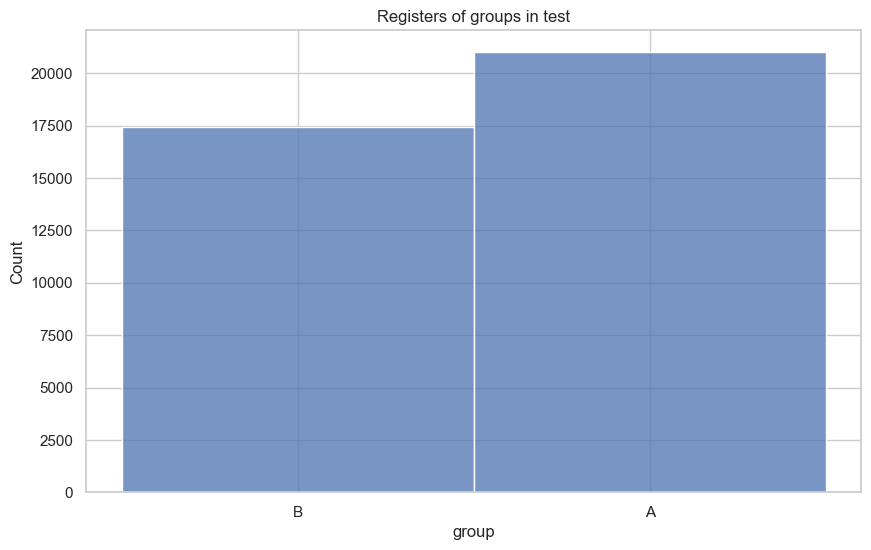

Total de registros do grupo A: 21011
Total de registros do grupo B: 17418


In [43]:
# criação histograma
sns.histplot(merged['group'])
plt.title('Registers of groups in test')
plt.show()
print(f"Total de registros do grupo A: {merged[merged['group'] == 'A']['group'].count()}")
print(f"Total de registros do grupo B: {merged[merged['group'] == 'B']['group'].count()}")

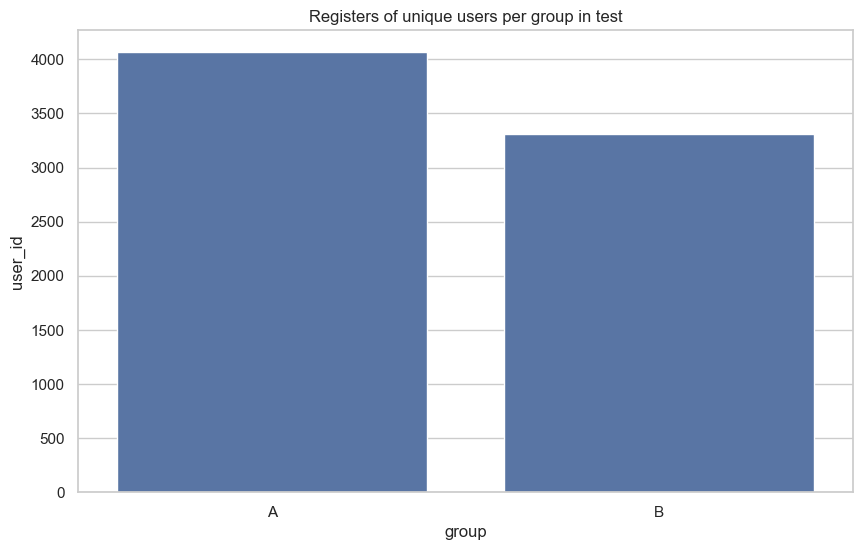

Total de usuários unívocos do grupo A: 4066
Total de usuários unívocos do grupo B: 3313


In [44]:
# criação gráfico de barras
sns.barplot(data=merged.groupby('group')['user_id'].nunique().reset_index(), x='group', y='user_id')
plt.title('Registers of unique users per group in test')
plt.show()

print(f"Total de usuários unívocos do grupo A: {merged[merged['group'] == 'A']['user_id'].nunique()}")
print(f"Total de usuários unívocos do grupo B: {merged[merged['group'] == 'B']['user_id'].nunique()}")

 Há um desequilíbrio aparente entre o número unívoco de usuários de cada grupo (A ~54.6% e B ~45.4%) e entre registros de eventos de cada grupo (A ~55% e B ~45%).

 A média de eventos por usuário do grupo A é ~5.1 e grupo B ~5.2.    

## Distribuição 'details'

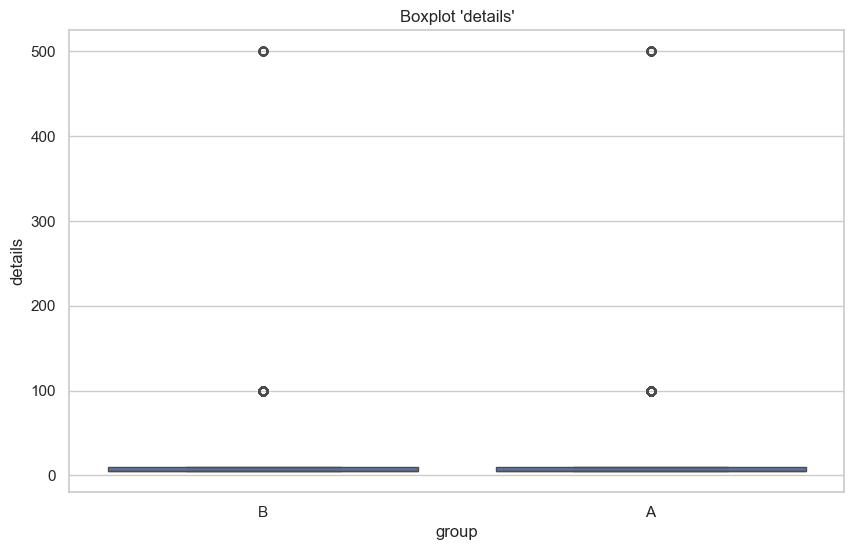

In [45]:
# criação boxplot
sns.boxplot(data=merged, y='details', x='group')
plt.title("Boxplot 'details'")
plt.show()

In [46]:
# descoberta localização percentis outliers 
print(np.percentile(merged[merged['event_name'] == 'purchase']['details'], [90, 99]))

[ 99.99 499.99]


## Taxa de conversão

In [102]:
merged['is_login'] = (merged['event_name'] == 'login').astype(int)
merged['is_product_page'] = (merged['event_name'] == 'product_page').astype(int)
merged['is_product_cart'] = (merged['event_name'] == 'product_cart').astype(int)
merged['is_purchase'] = (merged['event_name'] == 'purchase').astype(int)

In [103]:
user_level = merged.groupby(['user_id','group','day']).agg({
    'is_login':'max',
    'is_product_page':'max',
    'is_product_cart':'max',
    'is_purchase':'max'
}).reset_index()

In [104]:
user_level['valid_page'] = user_level['is_product_page']

user_level['valid_cart'] = (
    (user_level['is_product_cart'] == 1) &
    (user_level['valid_page'] == 1)
).astype(int)

user_level['valid_purchase'] = (
    (user_level['is_purchase'] == 1) &
    (user_level['valid_cart'] == 1)
).astype(int)

In [105]:
daily = user_level.groupby(['day','group']).agg({
    'is_login':'sum',
    'valid_page':'sum',
    'valid_cart':'sum',
    'valid_purchase':'sum'
}).reset_index()

In [106]:
daily['conv_page'] = daily['valid_page'] / daily['is_login']
daily['conv_cart'] = daily['valid_cart'] / daily['valid_page']
daily['conv_purchase'] = daily['valid_purchase'] / daily['valid_cart']
daily['conv_total'] = daily['valid_purchase'] / daily['is_login']

In [107]:
daily

,day,group,is_login,valid_page,valid_cart,valid_purchase,conv_page,conv_cart,conv_purchase,conv_total
0,7,A,536,357,100,21,0.67,0.28,0.21,0.04
1,7,B,536,344,114,43,0.64,0.33,0.38,0.08
2,8,A,588,407,111,31,0.69,0.27,0.28,0.05
3,8,B,566,355,122,42,0.63,0.34,0.34,0.07
4,9,A,612,406,117,37,0.66,0.29,0.32,0.06
5,9,B,593,380,132,44,0.64,0.35,0.33,0.07
6,10,A,639,421,141,40,0.66,0.33,0.28,0.06
7,10,B,599,402,141,52,0.67,0.35,0.37,0.09
8,11,A,660,436,129,39,0.66,0.30,0.30,0.06
9,11,B,603,396,128,37,0.66,0.32,0.29,0.06


### 'login' - 'product_page'

In [47]:
# criação agregado
login = merged[merged['event_name'].isin(['login'])].groupby(['day', 'group',])['user_id'].nunique().reset_index().rename(columns={'user_id': 'login'})

In [48]:
# criação agregado
product_page = merged[merged['event_name'].isin(['product_page'])].groupby(['day', 'group'])['user_id'].nunique().reset_index().rename(columns={'user_id': 'product_page'})

In [49]:
# junção 
conversions = login.merge(product_page, on=['day', 'group'], how='left')

In [50]:
# criação coluna conversão
conversions['conversion_1'] = (conversions['product_page'] / conversions['login']) * 100

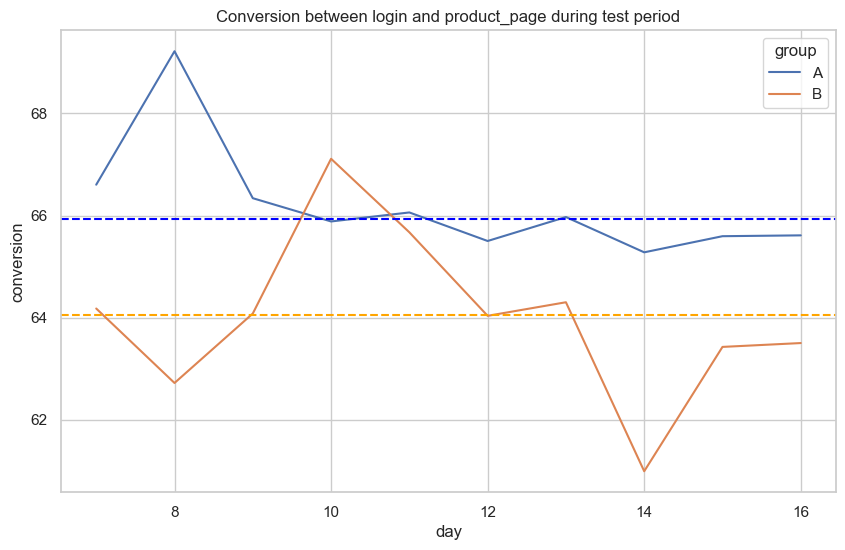

In [51]:
# criação gráfico
sns.lineplot(data=conversions, x='day', y='conversion_1', hue='group')
plt.title('Conversion between login and product_page during test period')
plt.ylabel('conversion')
plt.axhline(y=conversions[conversions['group'] == 'A']['conversion_1'].median(), color='blue', linestyle='--')
plt.axhline(y=conversions[conversions['group'] == 'B']['conversion_1'].median(), color='orange', linestyle='--')
plt.show()

In [52]:
# criação tabela dinâmica
conversion_table = conversions.pivot_table(
    index='day',
    columns='group',
    values='conversion_1')

In [53]:
# criação coluna diferença relativa
conversion_table['diff_rel'] = conversion_table['A'] / conversion_table['B'] - 1 

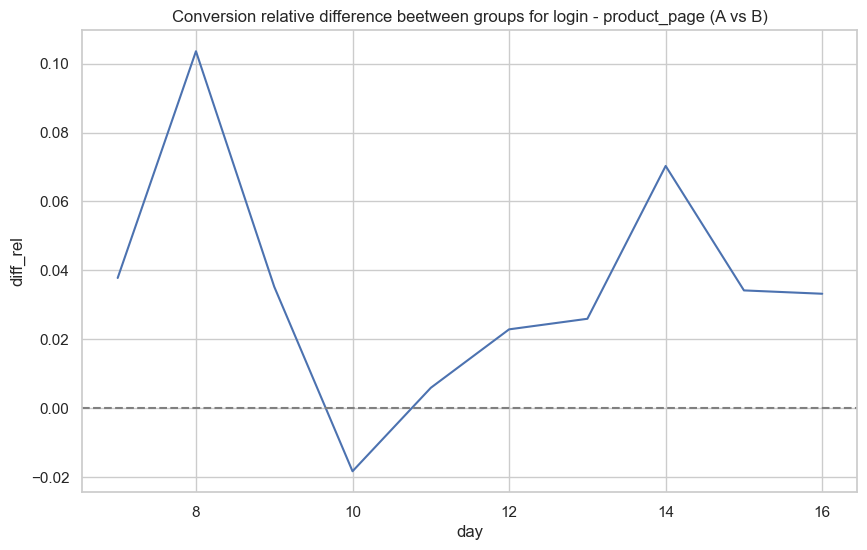

In [54]:
# criação gráfico
sns.lineplot(data=conversion_table, x=conversion_table.index, y='diff_rel')
plt.title('Conversion relative difference beetween groups for login - product_page (A vs B)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.show()

Grupo A apresentou as maiores taxas de conversão durante o teste para 'login' - 'product_page'.

### 'product_page' - 'product_cart'

In [55]:
# criação agregado
product_cart = merged[merged['event_name'].isin(['product_cart'])].groupby(['day', 'group'])['user_id'].nunique().reset_index().rename(columns={'user_id': 'product_cart'})

In [56]:
# união
conversions = conversions.merge(product_cart, on=['day', 'group'], how='left')

In [57]:
# criação coluna conversão
conversions['conversion_2'] = (conversions['product_cart'] / conversions['product_page']) * 100

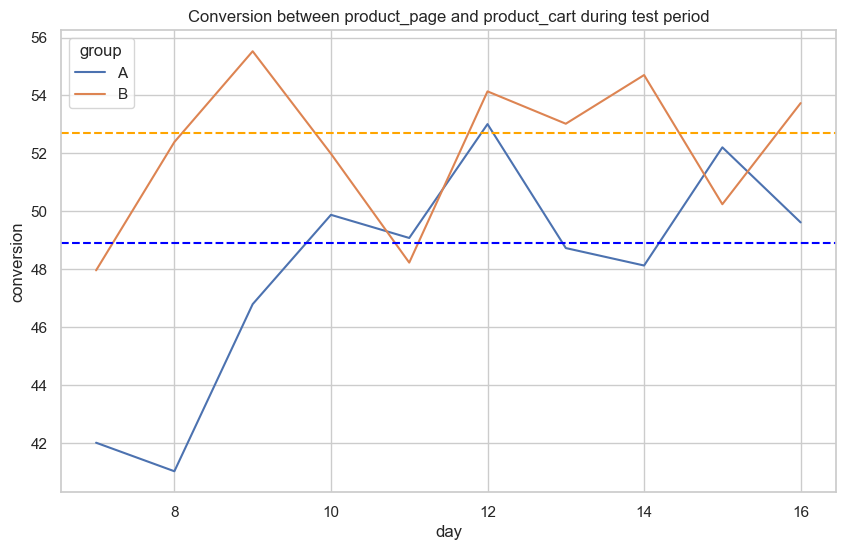

In [58]:
# criação gráfico
sns.lineplot(data=conversions, x='day', y='conversion_2', hue='group')
plt.title('Conversion between product_page and product_cart during test period')
plt.ylabel('conversion')
plt.axhline(y=conversions[conversions['group'] == 'A']['conversion_2'].median(), color='blue', linestyle='--')
plt.axhline(y=conversions[conversions['group'] == 'B']['conversion_2'].median(), color='orange', linestyle='--')
plt.show()

In [59]:
# criação tabela dinâmica
conversion_table = conversions.pivot_table(
    index='day',
    columns='group',
    values='conversion_2'
)

conversion_table['diff_rel'] = conversion_table['A'] / conversion_table['B'] - 1 

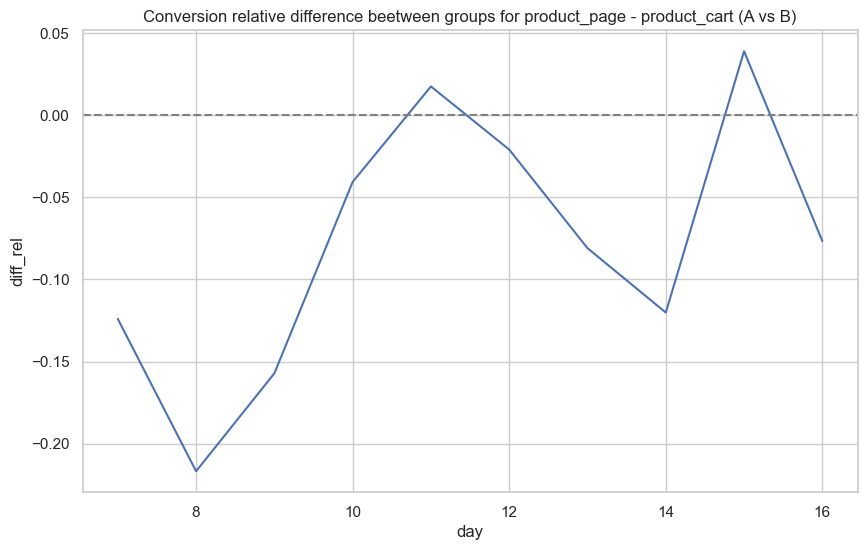

In [60]:
# criação gráfico
sns.lineplot(data=conversion_table, x=conversion_table.index, y='diff_rel')
plt.title('Conversion relative difference beetween groups for product_page - product_cart (A vs B)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.show()

Grupo A apresentou as menores taxas de conversão durante o teste para 'product_page' - 'product_cart'.

### 'product_cart' - 'purchase'

In [61]:
# criação agregado
purchase = merged[merged['event_name'].isin(['purchase'])].groupby(['day', 'group'])['user_id'].nunique().reset_index().rename(columns={'user_id': 'purchase'})

In [62]:
# união
conversions = conversions.merge(purchase, on=['day', 'group'], how='left')

In [63]:
# criação coluna conversão 
conversions['conversion_3'] = (conversions['purchase'] / conversions['product_cart']) * 100

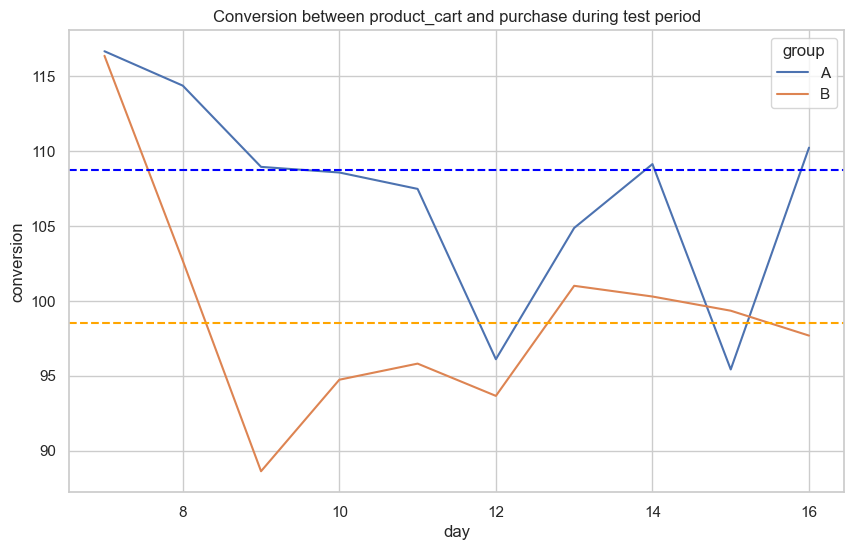

In [64]:
# criação gráfico
sns.lineplot(data=conversions, x='day', y='conversion_3', hue='group')
plt.title('Conversion between product_cart and purchase during test period')
plt.ylabel('conversion')
plt.axhline(y=conversions[conversions['group'] == 'A']['conversion_3'].median(), color='blue', linestyle='--')
plt.axhline(y=conversions[conversions['group'] == 'B']['conversion_3'].median(), color='orange', linestyle='--')
plt.show()

In [65]:
# criação tabela dinâmica
conversion_table = conversions.pivot_table(
    index='day',
    columns='group',
    values='conversion_3'
)

conversion_table['diff_rel'] = conversion_table['A'] / conversion_table['B'] - 1 

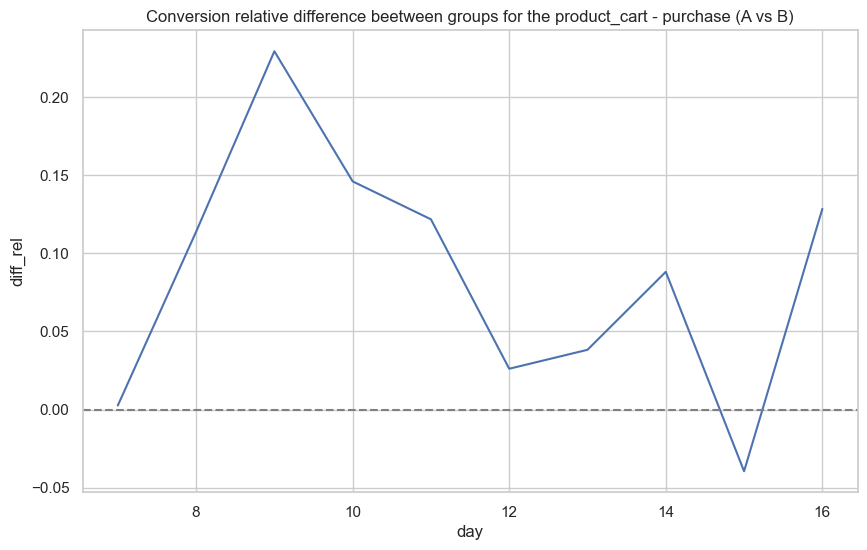

In [66]:
# criação gráfico
sns.lineplot(data=conversion_table, x=conversion_table.index, y='diff_rel')
plt.title('Conversion relative difference beetween groups for the product_cart - purchase (A vs B)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.show()

Grupo A apresentou as maiores taxas de conversão durante o teste para 'product_cart' - 'purchase'.

Vale destacar uma tendência entre ambos grupos para este passo do funil: a conversão de 'product_cart' - 'purchase' foi superior a 100% em alguns momentos, o que pode significar que nem todos os clientes que foram para o funil 'purchase' necessariamente passaram pelo funil 'product_cart'.

### 'login' - 'purchase'

In [91]:
# criação coluna conversão login - purchase
conversions['conversion_4'] = conversions['purchase'] / conversions['login'] * 100
conversions

,day,group,login,product_page,conversion_1,product_cart,conversion_2,purchase,conversion_3,conversion_4
0,7,A,536,357,66.60,150,42.02,175,116.67,32.65
1,7,B,536,344,64.18,165,47.97,192,116.36,35.82
2,8,A,588,407,69.22,167,41.03,191,114.37,32.48
3,8,B,566,355,62.72,186,52.39,191,102.69,33.75
4,9,A,612,406,66.34,190,46.80,207,108.95,33.82
5,9,B,593,380,64.08,211,55.53,187,88.63,31.53
6,10,A,639,421,65.88,210,49.88,228,108.57,35.68
7,10,B,599,402,67.11,209,51.99,198,94.74,33.06
8,11,A,660,436,66.06,214,49.08,230,107.48,34.85
9,11,B,603,396,65.67,191,48.23,183,95.81,30.35


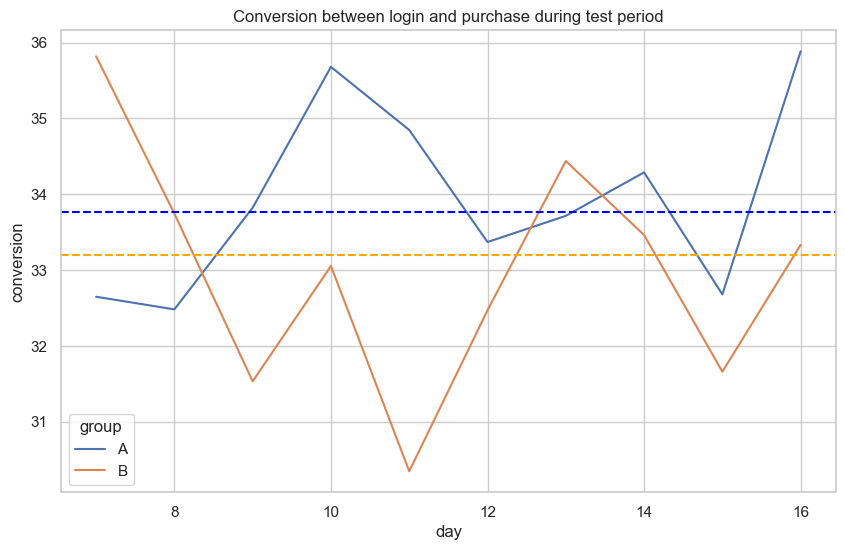

In [68]:
# criação gráfico
sns.lineplot(data=conversions, x='day', y='conversion_4', hue='group')
plt.title('Conversion between login and purchase during test period')
plt.ylabel('conversion')
plt.axhline(y=conversions[conversions['group'] == 'A']['conversion_4'].median(), color='blue', linestyle='--')
plt.axhline(y=conversions[conversions['group'] == 'B']['conversion_4'].median(), color='orange', linestyle='--')
plt.show()

In [69]:
# criação tabela dinâmica
conversion_table = conversions.pivot_table(
    index='day',
    columns='group',
    values='conversion_4'
)

conversion_table['diff_rel'] = conversion_table['A'] / conversion_table['B'] - 1 

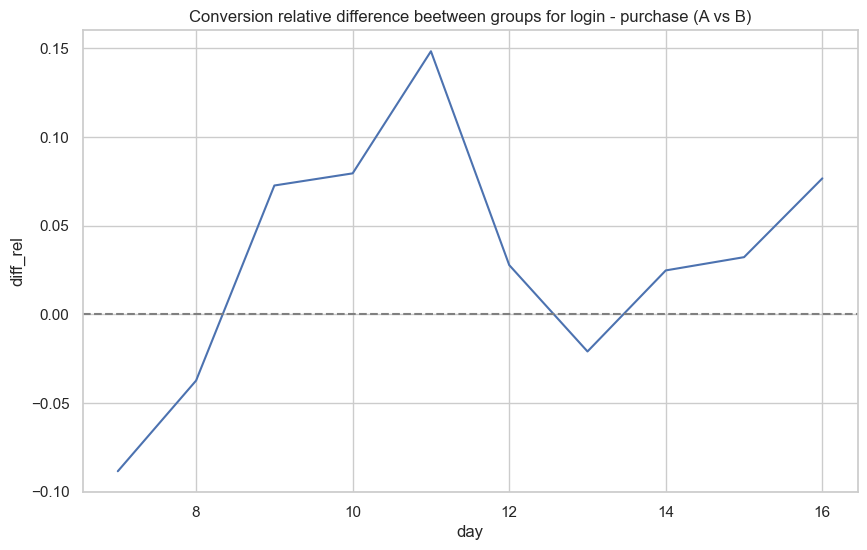

In [70]:
# criação gráfico
sns.lineplot(data=conversion_table, x=conversion_table.index, y='diff_rel')
plt.title('Conversion relative difference beetween groups for login - purchase (A vs B)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.show()

Em termos gerais, o grupo A apresentou as melhores taxas de conversão durante o teste 'login' - 'purchase'.

## Receita 

In [71]:
# criação objeto para análise receita
revenue = merged.groupby(['day', 'group'])['details'].sum().reset_index().rename(columns={'details': 'revenue'})

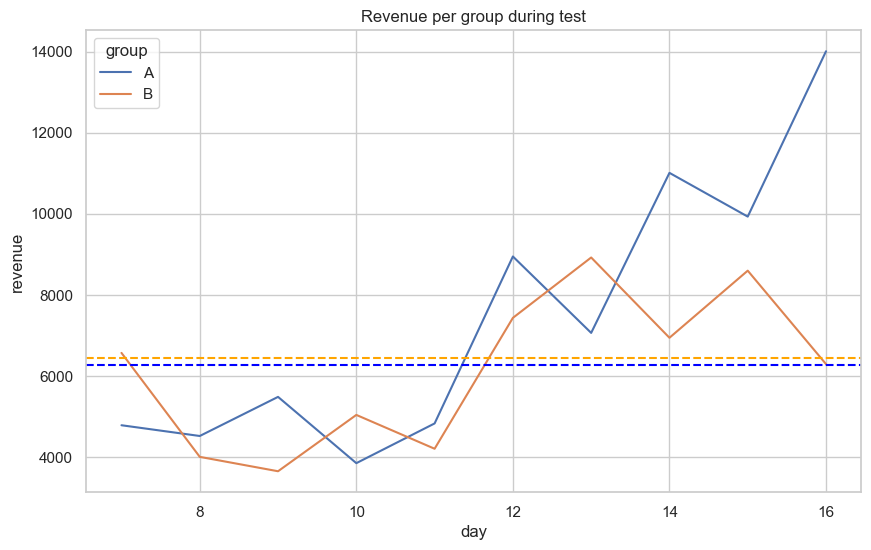

In [72]:
# criação gráfico de linha
sns.lineplot(data=revenue, x='day', y='revenue', hue='group')
plt.title('Revenue per group during test')
plt.ylabel('revenue')
plt.axhline(y=revenue[revenue['group'] == 'A']['revenue'].median(), color='blue', linestyle='--')
plt.axhline(y=revenue[revenue['group'] == 'B']['revenue'].median(), color='orange', linestyle='--')
plt.show()

In [73]:
# criação coluna cum_revenue
revenue['cum_revenue'] = revenue.groupby('group')['revenue'].cumsum()

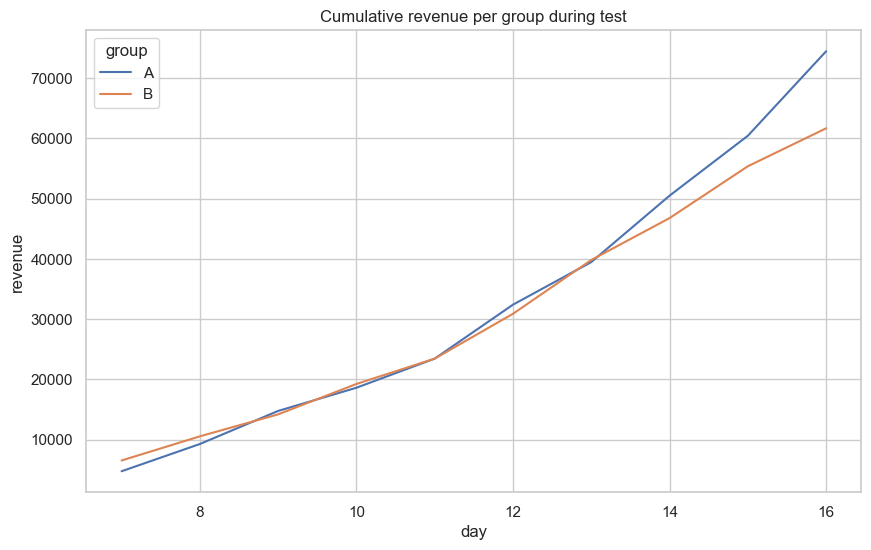

In [74]:
# criação gráfico de linha
sns.lineplot(data=revenue, x='day', y='cum_revenue', hue='group')
plt.title('Cumulative revenue per group during test')
plt.ylabel('revenue')
plt.show()

In [75]:
# criação tabela dinâmica
revenue_pivot = revenue.pivot(index='day', columns='group', values='cum_revenue')

In [76]:
# criação coluna diferença relativa
revenue_pivot['diff_rel'] = revenue_pivot['A'] / revenue_pivot['B'] - 1

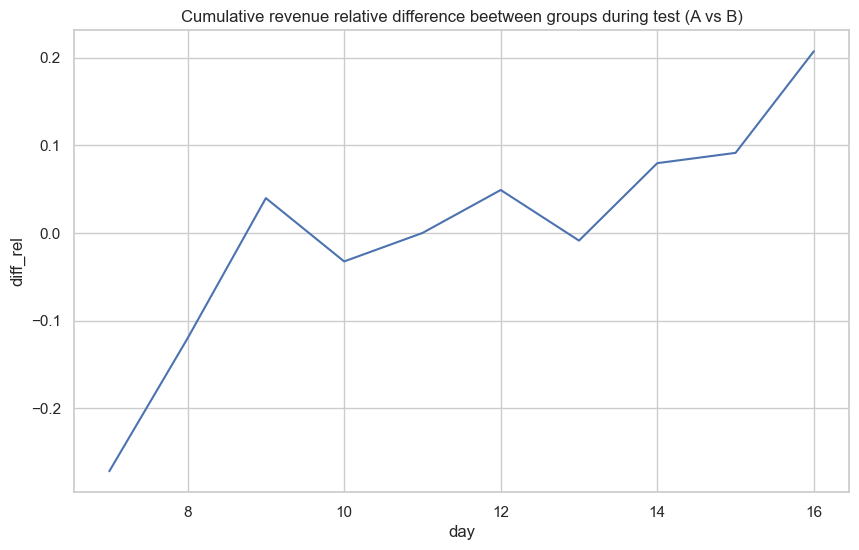

Receita total do grupo A durante o período de testes: $74419.26
Receita total do grupo B durante o período de testes: $61645.01


In [77]:
# criação gráfico de linhas
sns.lineplot(data=revenue_pivot, x=revenue_pivot.index, y='diff_rel')
plt.title('Cumulative revenue relative difference beetween groups during test (A vs B)')
#plt.axhline(y=0, color='gray', linestyle='--')
plt.show()

print(f"Receita total do grupo A durante o período de testes: ${revenue[revenue['group'] == 'A']['cum_revenue'].max():.2f}")
print(f"Receita total do grupo B durante o período de testes: ${revenue[revenue['group'] == 'B']['cum_revenue'].max():.2f}")

Usuários do grupo A apresentaram maior rentabilidade durante o teste com relação ao grupo B, tanto em números brutos (~$35k) e relativos (~40% acima ao fim do teste), com destaque ao dia 21 onde a receita foi acima do padrão observado.

## Volume de compras

In [78]:
# criação objeto
purchase = merged[merged['event_name'] == 'purchase'].groupby(['day', 'group'])['user_id'].nunique().reset_index()

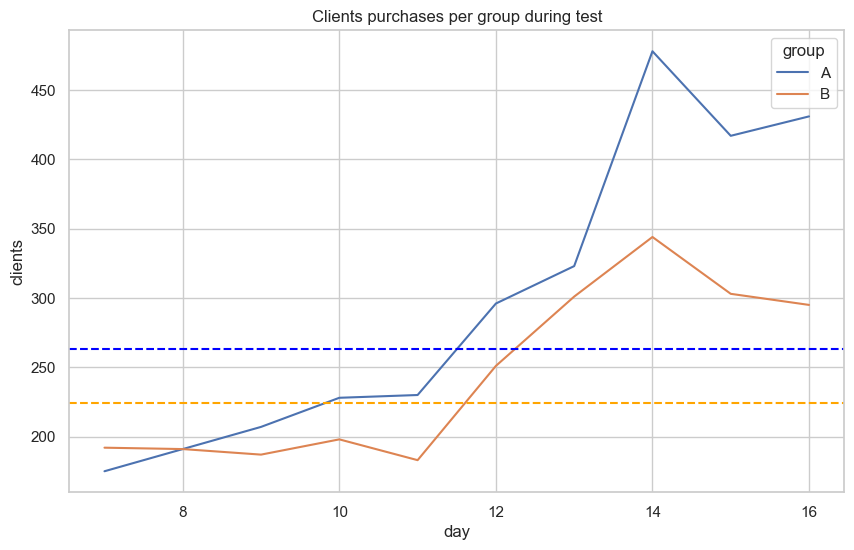

In [79]:
# criação gráfico
sns.lineplot(data=purchase, x='day', y='user_id', hue='group')
plt.title('Clients purchases per group during test')
plt.ylabel('clients')
plt.axhline(y=purchase[purchase['group'] == 'A']['user_id'].median(), color='blue', linestyle='--')
plt.axhline(y=purchase[purchase['group'] == 'B']['user_id'].median(), color='orange', linestyle='--')
plt.show()

In [80]:
# criação coluna valor acumulado
purchase['cum_users'] = purchase.groupby('group')['user_id'].cumsum()

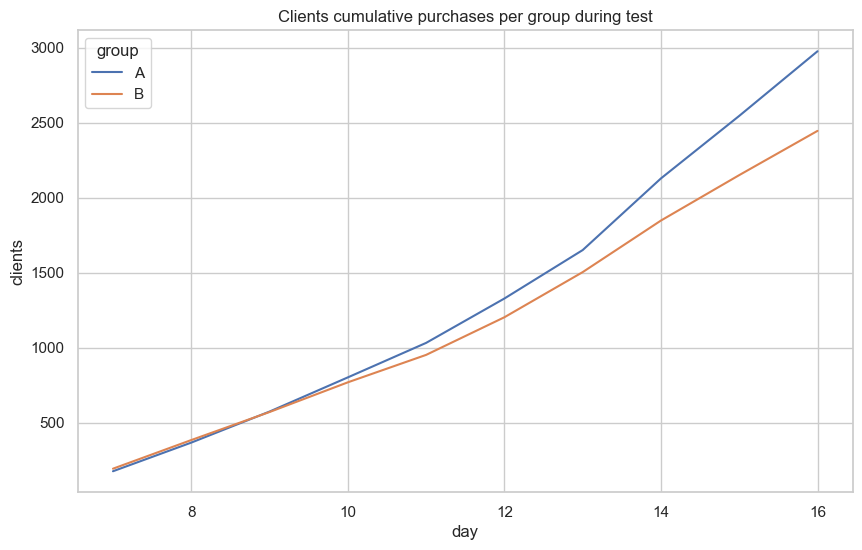

In [81]:
# criação gráfico
sns.lineplot(data=purchase, x='day', y='cum_users', hue='group')
plt.title('Clients cumulative purchases per group during test')
plt.ylabel('clients')
plt.show()

In [82]:
# criação tabela dinâmica
purchases_vol = purchase.pivot_table(index='day', columns='group', values='cum_users')

#criação coluna diferença relativa
purchases_vol['diff_rel'] = purchases_vol['A'] / purchases_vol['B'] - 1 

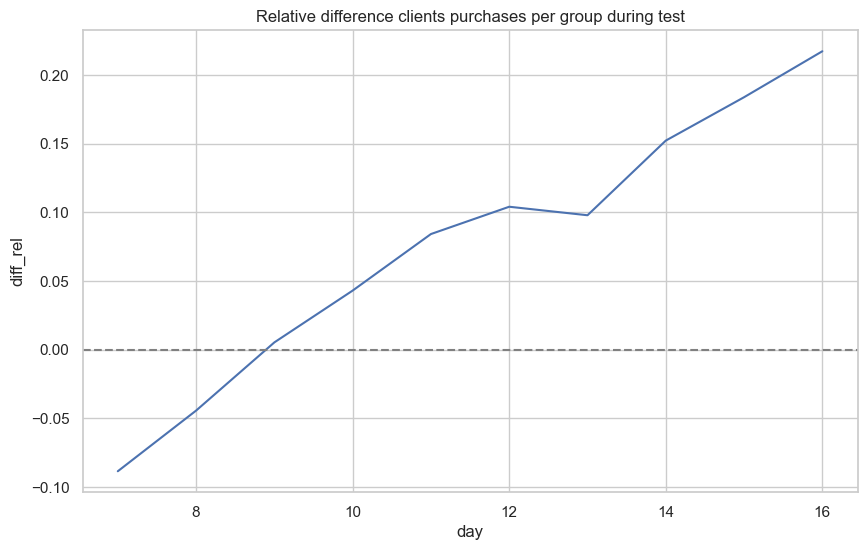

Número de clientes compradores total do grupo A durante o período de testes: 2976
Número de clientes compradores total do grupo B durante o período de testes: 2445


In [83]:
# criação gráfico
sns.lineplot(data=purchases_vol, x='day', y='diff_rel')
plt.title('Relative difference clients purchases per group during test')
plt.axhline(y=0, color='gray', linestyle='--')
plt.show()

print(f"Número de clientes compradores total do grupo A durante o período de testes: {purchase[purchase['group'] == 'A']['cum_users'].max()}")
print(f"Número de clientes compradores total do grupo B durante o período de testes: {purchase[purchase['group'] == 'B']['cum_users'].max()}")

Usuários do grupo A apresentaram maior volume de compras durante o teste, valores relativos (~30%) e absolutos (~2k). 

# Testes estatísticos

## Conversão 'login' - 'product_page'

In [84]:
# criação novo objeto


# Conclusões e Recomendações de Negócios